# Put uncertainty on a heat balance
### Sensitivity coefficients, correlated temperatures, and Monte Carlo verification

A steady heater can produce a perfectly reasonable nominal heat rate while still carrying uncertainty from its inputs. For $Q=\dot m c_p(T_{out}-T_{in})$, a shared sensor offset can largely cancel in the temperature difference, while independent errors cannot. This notebook combines sensitivity-based propagation with Monte Carlo sampling to quantify the standard uncertainty of the same heat balance under different temperature correlations.

The key idea is that the standard uncertainty is not a property of the nominal value alone: it depends on how each input varies and on whether the temperature readings move together. The first-order estimate from $u_Q^2 = J\Sigma J^T$ can be checked directly against the standard deviation from a Gaussian Monte Carlo experiment.

**Notation:** $\dot m$ denotes mass flow rate (kg/s), $c_p$ specific heat, $\Delta T=T_{out}-T_{in}$, $Q$ heat rate (W), $J$ the sensitivity row, and $\Sigma$ the input covariance matrix. Always order inputs as **[m, cp, Tin, Tout]**. Report standard uncertainty $u_Q$, not expanded uncertainty or a confidence interval.


## 1. Modeling assumptions and input data

This is a steady single-phase heater with negligible kinetic and potential energy changes, no shaft work, no phase change, and no heat loss. The inlet and outlet temperatures are measured with standard uncertainties of 0.20 K, while the mass flow and heat capacity carry their own independent uncertainty. The nominal values are

| Input | Nominal value | Standard uncertainty | Unit |
|---|---:|---:|---|
| $m$ | 10 | 0.10 | kg/s |
| $c_p$ | 4200 | 21 | J/(kg K) |
| $T_{in}$ | 300 | 0.20 | K |
| $T_{out}$ | 310 | 0.20 | K |

For the synthetic data here, the inputs are jointly Gaussian, all independent except for the temperature readings, which share correlation $\rho$. The comparison between $\rho=0$ and $\rho=0.9$ isolates how covariance alters the result even when the nominal heat rate is unchanged.

The control-volume energy balance reduces to the familiar steady heat-rate expression,

$$Q = \dot m\, c_p (T_{out}-T_{in}).$$

This gives a nominal value of

$$Q_0 = (10)(4200)(310-300) = 420{,}000\,\mathrm{W},$$

so the quantity of interest is not just the value of $Q$ itself, but the standard uncertainty $u_Q$ that accompanies it.

### Sensitivity row and covariance expansion

The sensitivity row is ordered as

$$J = \left[\frac{\partial Q}{\partial m},\,\frac{\partial Q}{\partial c_p},\,\frac{\partial Q}{\partial T_{in}},\,\frac{\partial Q}{\partial T_{out}}\right].$$

From $Q = \dot m c_p (T_{out}-T_{in})$,

$$\frac{\partial Q}{\partial m}=c_p(T_{out}-T_{in}),\qquad
\frac{\partial Q}{\partial c_p}=\dot m(T_{out}-T_{in}),\qquad
\frac{\partial Q}{\partial T_{in}}=-\dot m c_p,\qquad
\frac{\partial Q}{\partial T_{out}}=\dot m c_p.$$

At the nominal point these are approximately

$$J_0 = [42{,}000,\ 100,\ -42{,}000,\ 42{,}000],$$

with units W/(kg/s), W/(J/(kg K)), W/K, and W/K. The same units appear in the covariance propagation because each derivative multiplies a variance or covariance term with matching dimensions.

The first-order propagation law is

$$u_Q^2 = J \Sigma J^T,$$

where, in the prescribed ordering, the covariance matrix is

$$\Sigma = \begin{bmatrix}
 u_m^2 & 0 & 0 & 0\\
 0 & u_{cp}^2 & 0 & 0\\
 0 & 0 & u_{Tin}^2 & \rho u_{Tin}u_{Tout}\\
 0 & 0 & \rho u_{Tin}u_{Tout} & u_{Tout}^2
\end{bmatrix}.$$

Expanding the product gives

$$u_Q^2 = \left(\frac{\partial Q}{\partial m}\right)^2u_m^2
+\left(\frac{\partial Q}{\partial c_p}\right)^2u_{cp}^2
+\left(\frac{\partial Q}{\partial T_{in}}\right)^2u_{Tin}^2
+\left(\frac{\partial Q}{\partial T_{out}}\right)^2u_{Tout}^2
+2\frac{\partial Q}{\partial T_{in}}\frac{\partial Q}{\partial T_{out}}\rho u_{Tin}u_{Tout}.$$

The final term is the covariance contribution from the two temperature measurements. Because the derivatives have opposite signs, the product is negative, so positive correlation reduces the temperature-difference variance and therefore reduces $u_Q$. That cancellation is exactly why a shared sensor offset can be much less damaging than independent temperature uncertainty.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

INPUT_NAMES = ("m", "cp", "Tin", "Tout")
INPUT_UNITS = ("kg/s", "J/(kg K)", "K", "K")
x_nominal = np.array([10.0, 4200.0, 300.0, 310.0])
u_inputs = np.array([0.10, 21.0, 0.20, 0.20])
RHOS = (0.0, 0.9)
FD_FRACTION = 0.001
FD_TOL = 0.001  # 0.1% relative difference
MC_TOL = 0.02   # 2% relative difference
N_SAMPLES = 100_000

plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

## 2. Uncertainty propagation

The numerical implementation is straightforward once the derivatives and covariance structure are pinned down. The function `heat_rate(x)` evaluates the steady balance for a single vector or a batch of input samples, while `sensitivities(x)` returns the analytic Jacobian row at the nominal point. The covariance matrix is built from the standard uncertainties and the temperature correlation, with the off-diagonal temperature entries set to $\rho u_{Tin}u_{Tout}$.

The centered finite-difference check is useful because it confirms the analytic derivatives are not just algebraically consistent but numerically consistent with the heat-rate function itself. When the perturbation is small enough, the finite-difference estimate and the analytic derivative should agree to within around 0.1%.

Using the propagation law, the uncertainty is computed from the sensitivity row and the input covariance matrix. The result is a combined standard uncertainty in W, not an expanded interval or a confidence limit. This is the quantity that should be compared against Monte Carlo sampling when the model is smooth and mildly nonlinear.

In [2]:
def heat_rate(x):
    """Return Q in W; x has shape (4,) or (..., 4), ordered m, cp, Tin, Tout."""
    x = np.asarray(x, dtype=float)
    if x.shape[-1] != 4:
        raise ValueError("x must have four inputs ordered [m, cp, Tin, Tout].")
    m, cp, Tin, Tout = np.moveaxis(x, -1, 0)
    return m * cp * (Tout - Tin)


def sensitivities(x):
    """Return analytic sensitivity row J of shape (4,) at one input vector."""
    x = np.asarray(x, dtype=float)
    if x.shape != (4,):
        raise ValueError("x must be a single 4-element input vector.")
    m, cp, Tin, Tout = x
    dT = Tout - Tin
    return np.array([cp * dT, m * dT, -m * cp, m * cp], dtype=float)


def covariance(rho):
    """Return the 4-by-4 input covariance matrix for temperature correlation rho."""
    if not -1.0 <= rho <= 1.0:
        raise ValueError("rho must lie between -1 and 1.")
    Sigma = np.diag(u_inputs**2)
    Sigma[2, 3] = rho * u_inputs[2] * u_inputs[3]
    Sigma[3, 2] = Sigma[2, 3]
    return Sigma


def uncertainty(x, Sigma):
    """Return first-order combined standard uncertainty u_Q in W."""
    J = sensitivities(x)
    return float(np.sqrt(J @ Sigma @ J.T))


In [3]:
# Centered finite differences are independent of your analytic derivative formula.
h = FD_FRACTION * x_nominal
J_fd = np.empty(4)
for i in range(4):
    step = np.zeros(4)
    step[i] = h[i]
    J_fd[i] = (heat_rate(x_nominal + step) - heat_rate(x_nominal - step)) / (2 * h[i])

J_analytic = np.asarray(sensitivities(x_nominal), dtype=float)
fd_relative_error = np.abs(J_fd - J_analytic) / np.abs(J_analytic)
table = ["| Input | Perturbation (input units) | Analytic sensitivity (W/input unit) | Centered sensitivity (W/input unit) | Difference (%) |",
         "|---|---:|---:|---:|---:|"]
for i, name in enumerate(INPUT_NAMES):
    table.append(f"| {name} ({INPUT_UNITS[i]}) | {h[i]:.4g} | {J_analytic[i]:.6g} | {J_fd[i]:.6g} | {100 * fd_relative_error[i]:.6g} |")
display(Markdown("\n".join(table)))
assert np.all(fd_relative_error <= FD_TOL), "Derivative difference exceeds 0.1%."

| Input | Perturbation (input units) | Analytic sensitivity (W/input unit) | Centered sensitivity (W/input unit) | Difference (%) |
|---|---:|---:|---:|---:|
| m (kg/s) | 0.01 | 42000 | 42000 | 0 |
| cp (J/(kg K)) | 4.2 | 100 | 100 | 0 |
| Tin (K) | 0.3 | -42000 | -42000 | 3.70727e-12 |
| Tout (K) | 0.31 | 42000 | 42000 | 9.00833e-13 |

In [4]:
Q_nominal = float(heat_rate(x_nominal))
results = []
for rho in RHOS:
    Sigma = covariance(rho)
    np.testing.assert_allclose(Sigma, Sigma.T, rtol=0, atol=1e-12)
    np.testing.assert_allclose(np.diag(Sigma), u_inputs**2)
    expected_cov = rho * u_inputs[2] * u_inputs[3]
    assert np.isclose(Sigma[2, 3], expected_cov)
    assert np.isclose(Sigma[3, 2], expected_cov)
    mask = ~np.eye(4, dtype=bool)
    mask[2, 3] = mask[3, 2] = False
    assert np.all(Sigma[mask] == 0), "Other inputs must be independent."
    eigenvalues = np.linalg.eigvalsh(Sigma)
    assert np.min(eigenvalues) >= -1e-12, "Sigma must be positive semidefinite."
    u_Q = float(uncertainty(x_nominal, Sigma))
    results.append({"rho": rho, "Sigma": Sigma, "u_Q": u_Q,
                    "min_eigenvalue": float(eigenvalues.min())})

table = ["| Temperature correlation rho | Q (W) | First-order u_Q (W) | Relative u_Q (%) |",
         "|---:|---:|---:|---:|"]
for row in results:
    table.append(f"| {row['rho']:.1f} | {Q_nominal:.2f} | {row['u_Q']:.2f} | {100 * row['u_Q'] / abs(Q_nominal):.3f} |")
display(Markdown("\n".join(table)))

| Temperature correlation rho | Q (W) | First-order u_Q (W) | Relative u_Q (%) |
|---:|---:|---:|---:|
| 0.0 | 420000.00 | 12773.80 | 3.041 |
| 0.9 | 420000.00 | 6013.48 | 1.432 |

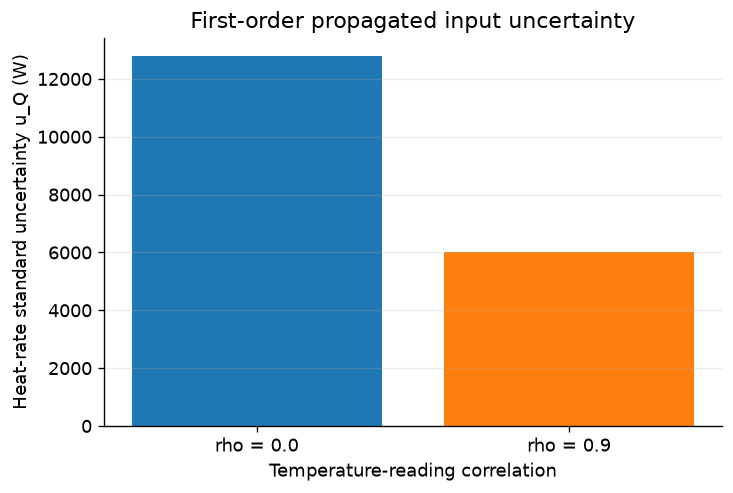

In [5]:
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
ax.bar([f"rho = {row['rho']:.1f}" for row in results],
       [row["u_Q"] for row in results], color=["tab:blue", "tab:orange"])
ax.set(xlabel="Temperature-reading correlation",
       ylabel="Heat-rate standard uncertainty u_Q (W)",
       title="First-order propagated input uncertainty")
ax.grid(axis="y", alpha=0.25)
plt.show()

## 3. Monte Carlo verification

With the first-order expression assembled, the next step is to test it against a direct Monte Carlo sample of the same Gaussian input model. The code draws 100,000 realizations from the input distribution for each correlation case, evaluates the heat-rate function on all of them, and computes the sample standard deviation using `ddof=1`.

The comparison is useful because a good agreement between the Monte Carlo value and the propagated estimate verifies that the local linear approximation is working for this problem. The same samples also show the effect of correlation directly: when the temperature readings move together, the variance of $T_{out}-T_{in}$ shrinks, and the propagated uncertainty falls even though the nominal heat rate remains identical.

This verification check is meant to test the uncertainty model, not the physical model itself. Monte Carlo agreement tells us the propagation formula is behaving as expected for this Gaussian, smooth, differentiable heat-balance problem; it does not establish whether the steady-energy model omits heat loss or other physics.

In [6]:
rng = np.random.default_rng(42)
for row in results:
    Sigma = row["Sigma"]
    samples = rng.multivariate_normal(
        mean=x_nominal,
        cov=Sigma,
        size=N_SAMPLES,
        check_valid="raise",
    )
    Q_samples = heat_rate(samples)
    mc_std = float(np.std(Q_samples, ddof=1))
    row["mc_std"] = mc_std
    row["mc_relative_error"] = abs(mc_std - row["u_Q"]) / row["u_Q"]


In [7]:
table = ["| rho | Samples | First-order u_Q (W) | Monte Carlo s_Q (W) | Difference (%) | Within 2%? |",
         "|---:|---:|---:|---:|---:|:---:|"]
for row in results:
    passed = row["mc_relative_error"] <= MC_TOL
    table.append(f"| {row['rho']:.1f} | {N_SAMPLES:,} | {row['u_Q']:.2f} | {row['mc_std']:.2f} | {100 * row['mc_relative_error']:.3f} | {'PASS' if passed else 'FAIL'} |")
display(Markdown("\n".join(table)))

| rho | Samples | First-order u_Q (W) | Monte Carlo s_Q (W) | Difference (%) | Within 2%? |
|---:|---:|---:|---:|---:|:---:|
| 0.0 | 100,000 | 12773.80 | 12784.86 | 0.087 | PASS |
| 0.9 | 100,000 | 6013.48 | 6015.74 | 0.038 | PASS |

### Temperature cancellation check

Use

$$\operatorname{Var}(T_{out}-T_{in}) = u_{Tout}^2 + u_{Tin}^2 - 2\rho u_{Tin}u_{Tout}.$$

At $\rho=1$ with equal standard uncertainties, the temperature-difference variance collapses to zero because both readings carry the same offset. In other words, a common sensor bias adds equally to both temperatures and cancels in the difference $T_{out}-T_{in}$. The full heat-rate uncertainty does not vanish, because the mass-flow and heat-capacity terms remain uncertain: only the shared temperature offset cancels, not the physical and process uncertainties in $m$ and $c_p$. This is why the covariance term is important and why the same sensor drift can be nearly invisible in a differential measurement while still leaving the overall heat-rate estimate uncertain.


In [8]:
rho_sweep = np.array([0.0, 0.9, 0.99, 1.0])
delta_T_variances = (u_inputs[2]**2 + u_inputs[3]**2
                     - 2 * rho_sweep * u_inputs[2] * u_inputs[3])
assert np.all(np.diff(delta_T_variances) < 0)
assert np.isclose(delta_T_variances[-1], 0.0, atol=1e-12)

# An equal additive offset should not change the heat rate.
x_shifted = x_nominal.copy()
x_shifted[2:] += 5.0  # shared +5 K offset
np.testing.assert_allclose(heat_rate(x_shifted), Q_nominal, rtol=0, atol=1e-8)

# At rho=1 only the m and cp contributions remain.
Sigma_perfect = covariance(1.0)
assert np.linalg.eigvalsh(Sigma_perfect).min() >= -1e-12
u_Q_perfect = uncertainty(x_nominal, Sigma_perfect)
remaining_variance = np.sum((J_analytic[:2] * u_inputs[:2])**2)
np.testing.assert_allclose(u_Q_perfect**2, remaining_variance, rtol=1e-10)
assert u_Q_perfect > 0
print("PASS: shared temperature offset cancels; flow and heat-capacity uncertainty remain.")

PASS: shared temperature offset cancels; flow and heat-capacity uncertainty remain.


## 4. Results and comparison

The first-order propagation gives the standard uncertainty for each temperature-correlation case, and the Monte Carlo sample provides an independent check of the same quantity. The plotted comparison shows the expected pattern: the positive correlation case has a smaller propagated uncertainty because the common temperature variation cancels in the temperature difference.


The strongest check is that the Monte Carlo standard deviation stays within 2% of the first-order value for both $\rho=0$ and $\rho=0.9$. That agreement supports the Gaussian linearization here, while still leaving room for model-form uncertainty outside the statistical description.

In [9]:
assert np.isclose(Q_nominal, 420_000.0), "Nominal heat rate must be 420000 W."
np.testing.assert_allclose(heat_rate(np.vstack([x_nominal, x_nominal])),
                           [Q_nominal, Q_nominal])
assert J_analytic.shape == (4,)
assert np.all(fd_relative_error <= FD_TOL)
assert len(results) == 2 and tuple(row["rho"] for row in results) == RHOS
for row in results:
    assert np.isfinite(row["u_Q"]) and row["u_Q"] > 0
    np.testing.assert_allclose(row["u_Q"]**2,
                               J_analytic @ row["Sigma"] @ J_analytic.T)
    assert np.isfinite(row["mc_std"]) and row["mc_std"] > 0
    assert row["mc_relative_error"] <= MC_TOL, "Monte Carlo difference exceeds 2%."
assert results[1]["u_Q"] < results[0]["u_Q"], "Positive correlation should reduce u_Q here."
print("PASS: nominal balance, vectorization, first-order propagation, "
      "derivatives within 0.1%, and Monte Carlo within 2% for both cases.")

PASS: nominal balance, vectorization, first-order propagation, derivatives within 0.1%, and Monte Carlo within 2% for both cases.


## 5. Discussion, limitations, and reading

The two cases have the same nominal heat rate, but very different propagated standard uncertainties. With independent temperature readings ($\rho=0$), both inlet and outlet uncertainty contribute directly to the variance of the temperature difference. With strong positive correlation ($\rho=0.9$), the covariance term partially cancels those contributions, so the uncertainty in $T_{out}-T_{in}$ drops even though the mean heat rate stays the same. The remaining uncertainty comes from the flow rate and heat-capacity terms, which do not cancel.

This is why a shared sensor offset can be almost invisible in a differential heat balance while the overall heat-rate uncertainty is still nonzero. The calculation here is a statistical uncertainty propagation, not a validation of the underlying model. A small propagated uncertainty does not mean the steady-energy balance omits no physics; it only means the chosen Gaussian input model and its local linearization are behaving consistently.

Two limitations are worth keeping explicit. First, the first-order propagation and the Monte Carlo check are only as good as the assumed Gaussian input model and covariance structure; they are not a substitute for checking whether the measured inputs are actually distributed that way. Second, model-form uncertainty such as neglected heat loss, unmodeled flow maldistribution, or a biased calibration remains outside this calculation and would require a separate validation study.

As a useful extension, one can test negative correlation, such as $\rho=-0.9$, and predict that it will increase the uncertainty because the inlet and outlet temperature errors reinforce one another in the temperature difference. The same NIST discussion used in the propagation formula provides the conceptual foundation for this computation.

**Reading:** NIST Technical Note 1297, [Section 5: Combined Standard Uncertainty](https://www.nist.gov/pml/nist-technical-note-1297/nist-tn-1297-5-combined-standard-uncertainty) and [Appendix A: Law of Propagation of Uncertainty, Eq. (A-3)](https://www.nist.gov/pml/nist-technical-note-1297/nist-tn-1297-appendix-law-propagation-uncertainty). Appendix A gives the covariance-aware propagation formula in the same form as the sensitivity-vector calculation used here.
